--- Diagnóstico RayExtract ---
Total de objetos brutos extraídos: 949
Total de árvores após filtro (Altura >= 5.0m e DAP >= 5.0cm): 462
Ruídos/Galhos removidos: 487

--- Estatísticas Descritivas (Árvores Filtradas) ---
       Altura_m  DAP_cm
count    462.00  462.00
mean      16.76   26.42
std        7.10   15.37
min        5.01    6.85
25%       11.41   16.10
50%       16.22   21.68
75%       21.41   32.44
max       30.10  110.28


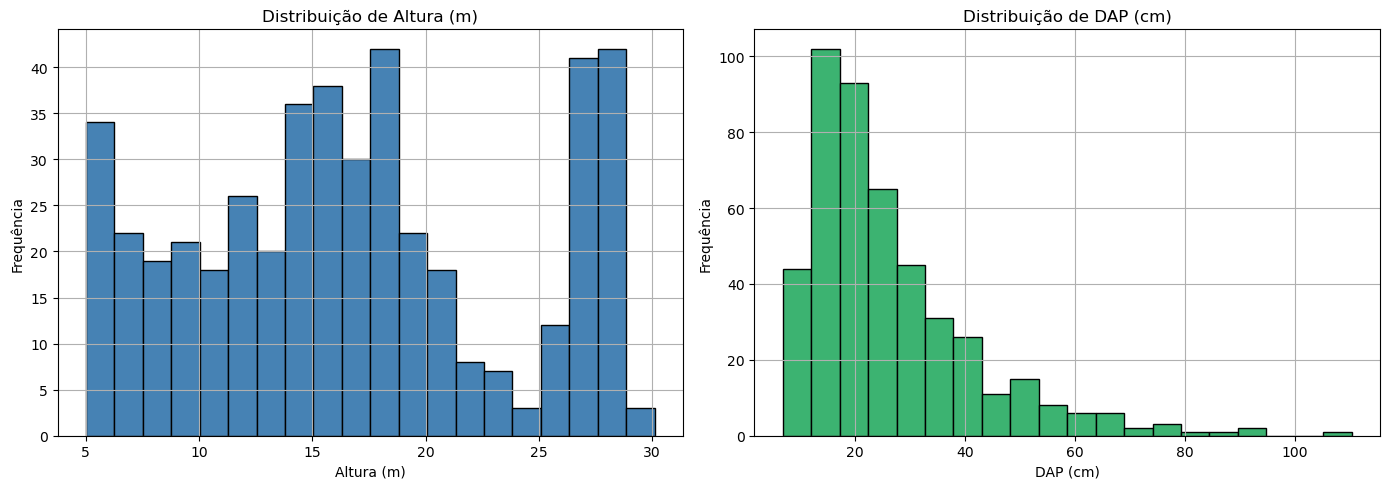

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analisar_rayextract(filepath, altura_minima=5.0, dap_minimo=0.05):
    dados_arvores = []
    
    with open(filepath, 'r') as f:
        linhas = f.readlines()
        
    for linha in linhas:
        linha = linha.strip()
        # Pular linhas vazias e o cabeçalho
        if not linha or linha.startswith('#') or linha.startswith('height'):
            continue
            
        partes = linha.split(',')
        
        # O cabeçalho possui 7 atributos gerais da árvore antes das informações dos segmentos
        if len(partes) >= 7:
            try:
                height = float(partes[0])
                crown_radius = float(partes[1])
                dimension = float(partes[2])
                monocotal = float(partes[3])
                dbh = float(partes[4])
                bend = float(partes[5])
                branch_slope = float(partes[6])
                
                # Cada segmento possui 14 atributos
                num_segmentos = (len(partes) - 7) // 14
                
                dados_arvores.append({
                    'Altura_m': height,
                    'Raio_Copa_m': crown_radius,
                    'DAP_m': dbh,
                    'DAP_cm': dbh * 100,
                    'Num_Segmentos': num_segmentos
                })
            except ValueError:
                continue
                
    df = pd.DataFrame(dados_arvores)
    
    print(f"--- Diagnóstico RayExtract ---")
    print(f"Total de objetos brutos extraídos: {len(df)}")
    
    # Aplicação de filtros biológicos para eucalipto comercial
    df_filtrado = df[(df['Altura_m'] >= altura_minima) & (df['DAP_m'] >= dap_minimo)]
    
    print(f"Total de árvores após filtro (Altura >= {altura_minima}m e DAP >= {dap_minimo*100}cm): {len(df_filtrado)}")
    print(f"Ruídos/Galhos removidos: {len(df) - len(df_filtrado)}\n")
    
    print("--- Estatísticas Descritivas (Árvores Filtradas) ---")
    print(df_filtrado[['Altura_m', 'DAP_cm']].describe().round(2))
    
    # Plotagem dos Histogramas
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df_filtrado['Altura_m'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_title('Distribuição de Altura (m)')
    axes[0].set_xlabel('Altura (m)')
    axes[0].set_ylabel('Frequência')
    
    df_filtrado['DAP_cm'].hist(ax=axes[1], bins=20, color='mediumseagreen', edgecolor='black')
    axes[1].set_title('Distribuição de DAP (cm)')
    axes[1].set_xlabel('DAP (cm)')
    axes[1].set_ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()

    return df_filtrado

# Execução do script com o nome do arquivo atual
# Ajuste 'altura_minima' e 'dap_minimo' conforme as regras de negócio do seu plantio.
df_limpo = analisar_rayextract('../talhao_62_1ha_trees_info.txt', altura_minima=5.0, dap_minimo=0.05)

In [2]:
df_limpo.shape

(462, 5)

In [3]:
import pandas as pd

# O arquivo não tem header — estrutura baseada no conteúdo
# Os valores separados por vírgula têm, na posição 4 (índice 4), o tree_id
# Cada linha corresponde a uma fatia de árvore, não uma árvore

lines = []
with open('../talhao_62_1ha_trees_info.txt', 'r') as f:
    raw = f.read()

# O arquivo tem múltiplos "blocos" separados por sumários numéricos no início de cada árvore
# A forma mais robusta é extrair os tree_ids únicos da coluna de índice 4
import re
# Pegar todos os números na posição correta após as coordenadas
# Cada linha de dados tem formato: x,y,z,r,tree_id,point_id,...
entries = []
for line in raw.replace('\n', ' ').split(' 44'):
    for item in line.split(','):
        pass  # estrutura complexa

# Método direto: contar tree_ids únicos >= 0 (excluir -1 que é "nenhuma árvore")
# A coluna tree_id parece ser a 5ª após as coordenadas
# Vamos tentar pandas com separador vírgula, ignorando as linhas de sumário

try:
    df = pd.read_csv('../talhao_62_1ha_trees_info.txt', header=None, on_bad_lines='skip')
    # Identificar qual coluna tem os tree_ids (inteiros, range razoável)
    print(df.dtypes)
    print(df.head(3))
    # Tree ID provavelmente está em uma coluna com valores 0-2000
    for col in df.columns:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if vals.between(0, 3000).mean() > 0.8 and vals.nunique() < 3000:
            print(f"Col {col}: {vals.nunique()} únicos, range {vals.min()}-{vals.max()}")
except Exception as e:
    print(e)

0    object
1    object
2    object
3    object
4    object
5    object
dtype: object
                                                   0             1  \
0  # Tree file. Optional per-tree attributes (e.g...  crown_radius   

                    2  3  4                                                  5  
0   ') followed by 'x  y  z  radius' and any additional per-segment attribu...  


In [4]:
import re
import numpy as np
from collections import defaultdict

# ── Leitura ──────────────────────────────────────────────────────────────────
with open('../talhao_62_1ha_trees_info.txt', 'r') as f:
    raw = f.read()

# ── Estrutura do arquivo ──────────────────────────────────────────────────────
# Cada árvore começa com uma linha de sumário:
#   height,crown_radius,dimension,monocotal,DBH,bend,branch_slope
# seguida de segmentos:
#   x,y,z,radius,parent_id,section_id,volume,diameter,length,...
#
# O segmento raiz (parent_id = -1) representa o tronco base da árvore.
# Os atributos de sumário (height, DBH, etc.) são por árvore, não por segmento.

# ── Extrair blocos por árvore ─────────────────────────────────────────────────
# Cada bloco: linha de sumário + segmentos até o próximo sumário
# Separador: linha que começa COM número (sumário) vs começa COM espaço (segmento)

# Remove header
header_end = raw.index('\n', raw.index('children')) + 1
body = raw[header_end:]

# Dividir em blocos de árvore — cada bloco começa no sumário (não tem espaço inicial)
# O sumário e seus segmentos estão todos em uma linha contínua (separados por ", ")
# Estratégia: dividir pelo padrão de início de bloco (dígito após newline ou início)
blocks_raw = re.split(r'(?:^|\n)(?=[\d.-])', body)
blocks_raw = [b.strip() for b in blocks_raw if b.strip()]

print(f"Total de árvores (blocos): {len(blocks_raw)}")

# ── Parser de bloco ────────────────────────────────────────────────────────────
trees = []

for block in blocks_raw:
    # Separar sumário dos segmentos
    # Sumário: tudo antes do primeiro " x,y,z" (segmento tem coordenada UTM ~443xxx)
    # Segmentos: cada item separado por ", " que começa com coordenada
    
    # Split por ", " seguido de coordenada UTM (44xxxx ou 45xxxx)
    parts = re.split(r',\s+(?=4[34]\d{4}\.\d)', block)
    
    if len(parts) < 2:
        continue
    
    # Sumário: primeira parte
    summary_vals = parts[0].split(',')
    try:
        tree_height   = float(summary_vals[0])
        crown_radius  = float(summary_vals[1])
        dbh_summary   = float(summary_vals[4])   # DBH do sumário
    except (IndexError, ValueError):
        continue
    
    # Segmentos
    segments = []
    for seg_str in parts[1:]:
        seg_vals = seg_str.strip().split(',')
        try:
            x          = float(seg_vals[0])
            y          = float(seg_vals[1])
            z          = float(seg_vals[2])
            radius     = float(seg_vals[3])
            parent_id  = int(float(seg_vals[4]))
            section_id = float(seg_vals[5])
            volume     = float(seg_vals[6])
            diameter   = float(seg_vals[7])
            length     = float(seg_vals[8])
        except (IndexError, ValueError):
            continue
        segments.append({
            'x': x, 'y': y, 'z': z,
            'radius': radius,
            'parent_id': parent_id,
            'section_id': section_id,
            'volume': volume,
            'diameter': diameter,
            'length': length,
        })
    
    if not segments:
        continue
    
    # Volume total da árvore = soma dos volumes dos segmentos
    total_volume = sum(s['volume'] for s in segments)
    
    # Altura = atributo do sumário (já calculado pelo RayExtract)
    # DAP = atributo do sumário (DBH field)
    # Alternativamente: diâmetro do segmento raiz (parent_id == -1)
    root_segs = [s for s in segments if s['parent_id'] == -1]
    root_diameter = root_segs[0]['diameter'] * 100 if root_segs else None  # m -> cm
    
    trees.append({
        'height_m':      tree_height,
        'crown_radius_m': crown_radius,
        'dbh_summary_cm': dbh_summary * 100,   # m -> cm (campo DBH do sumário)
        'dbh_root_cm':    root_diameter,
        'volume_m3':      total_volume,
        'n_segments':     len(segments),
    })

print(f"Árvores parseadas com sucesso: {len(trees)}")

# ── Análise geral ──────────────────────────────────────────────────────────────
import statistics

def stats(values, label):
    v = [x for x in values if x is not None and not np.isnan(x)]
    if not v:
        print(f"  {label}: sem dados")
        return
    print(f"  {label}:")
    print(f"    n={len(v)}, mean={np.mean(v):.3f}, median={np.median(v):.3f}, "
          f"std={np.std(v):.3f}, min={min(v):.3f}, max={max(v):.3f}")

print("\n=== ESTATÍSTICAS GERAIS (todas as árvores) ===")
stats([t['height_m']       for t in trees], "Altura (m)")
stats([t['dbh_summary_cm'] for t in trees], "DAP sumário (cm)")
stats([t['dbh_root_cm']    for t in trees], "DAP segmento raiz (cm)")
stats([t['volume_m3']      for t in trees], "Volume total (m³)")
stats([t['n_segments']     for t in trees], "N segmentos por árvore")

# ── Zeros e outliers ───────────────────────────────────────────────────────────
vols = [t['volume_m3'] for t in trees]
heights = [t['height_m'] for t in trees]

n_zero_vol    = sum(1 for v in vols if v == 0)
n_zero_height = sum(1 for h in heights if h == 0)
n_outlier     = sum(1 for v in vols if v >= 1000)
n_valid       = sum(1 for i, v in enumerate(vols) if 0 < v < 1000 and heights[i] > 0)

print(f"\n=== COMPLETUDE ===")
print(f"  Volume = 0:          {n_zero_vol}  ({n_zero_vol/len(trees)*100:.1f}%)")
print(f"  Altura = 0:          {n_zero_height}  ({n_zero_height/len(trees)*100:.1f}%)")
print(f"  Outlier (vol≥1000):  {n_outlier}  ({n_outlier/len(trees)*100:.1f}%)")
print(f"  Válidos (vol>0, vol<1000, h>0): {n_valid}  ({n_valid/len(trees)*100:.1f}%)")

# ── Válidos ────────────────────────────────────────────────────────────────────
valid = [t for t in trees if 0 < t['volume_m3'] < 1000 and t['height_m'] > 0]
print(f"\n=== ESTATÍSTICAS — VÁLIDOS (n={len(valid)}) ===")
stats([t['height_m']       for t in valid], "Altura (m)")
stats([t['dbh_summary_cm'] for t in valid], "DAP sumário (cm)")
stats([t['dbh_root_cm']    for t in valid], "DAP segmento raiz (cm)")
stats([t['volume_m3']      for t in valid], "Volume (m³)")

# ── Filtro aceitável (DAP 5-40 cm, vol 0.01-5.0 m³) ──────────────────────────
DAP_MIN, DAP_MAX = 5, 40
VOL_MIN, VOL_MAX = 0.01, 5.0

filtered = [t for t in trees
            if DAP_MIN <= t['dbh_summary_cm'] <= DAP_MAX
            and VOL_MIN <= t['volume_m3'] <= VOL_MAX]

print(f"\n=== FILTRADO (DAP {DAP_MIN}-{DAP_MAX} cm, vol {VOL_MIN}-{VOL_MAX} m³) ===")
print(f"  n = {len(filtered)} ({len(filtered)/len(trees)*100:.1f}% do total)")
stats([t['height_m']       for t in filtered], "Altura (m)")
stats([t['dbh_summary_cm'] for t in filtered], "DAP (cm)")
stats([t['volume_m3']      for t in filtered], "Volume (m³)")

# ── Distribuição de alturas (histograma simples) ───────────────────────────────
print(f"\n=== DISTRIBUIÇÃO DE ALTURAS (válidos) ===")
bins = [(0,5),(5,10),(10,15),(15,20),(20,25),(25,30),(30,35),(35,100)]
for lo, hi in bins:
    n = sum(1 for t in valid if lo <= t['height_m'] < hi)
    bar = '█' * (n // 2)
    print(f"  {lo:3}-{hi:3} m: {n:4}  {bar}")

# ── Distribuição de volumes (válidos) ──────────────────────────────────────────
print(f"\n=== DISTRIBUIÇÃO DE VOLUMES (válidos) ===")
vbins = [(0,0.1),(0.1,0.3),(0.3,0.5),(0.5,1),(1,2),(2,5),(5,10),(10,50),(50,1000)]
for lo, hi in vbins:
    n = sum(1 for t in valid if lo <= t['volume_m3'] < hi)
    bar = '█' * (n // 2)
    print(f"  {lo:.1f}-{hi:.1f} m³: {n:4}  {bar}")

# ── Outlier extremo ────────────────────────────────────────────────────────────
outliers = [t for t in trees if t['volume_m3'] >= 1000]
if outliers:
    print(f"\n=== OUTLIERS EXTREMOS (vol ≥ 1000 m³) ===")
    for t in outliers:
        print(f"  vol={t['volume_m3']:.1f} m³, h={t['height_m']:.1f} m, "
              f"dap={t['dbh_summary_cm']:.1f} cm, n_seg={t['n_segments']}")

# ── Massa (se disponível) ──────────────────────────────────────────────────────
# Não há campo de massa direto no sumário visível — ignorar

print("\n=== RESUMO PARA O RELATÓRIO ===")
print(f"  Total detectado:     {len(trees)}")
print(f"  Válidos (vol>0, h>0, vol<1000): {n_valid} ({n_valid/len(trees)*100:.1f}%)")
print(f"  Zeros:               {n_zero_vol} ({n_zero_vol/len(trees)*100:.1f}%)")
print(f"  Outlier extremo:     {n_outlier}")
print(f"  Filtrado aceitável:  {len(filtered)} ({len(filtered)/len(trees)*100:.1f}%)")
if valid:
    vv = [t['volume_m3'] for t in valid]
    hv = [t['height_m'] for t in valid]
    dv = [t['dbh_summary_cm'] for t in valid]
    print(f"\n  Válidos — mediana vol:  {np.median(vv):.3f} m³")
    print(f"  Válidos — mediana h:    {np.median(hv):.1f} m")
    print(f"  Válidos — mediana DAP:  {np.median(dv):.1f} cm")

Total de árvores (blocos): 949
Árvores parseadas com sucesso: 949

=== ESTATÍSTICAS GERAIS (todas as árvores) ===
  Altura (m):
    n=949, mean=9.686, median=4.752, std=8.498, min=1.141, max=30.103
  DAP sumário (cm):
    n=949, mean=15.511, median=10.390, std=15.273, min=0.000, max=110.280
  DAP segmento raiz (cm):
    n=949, mean=17.917, median=11.660, std=16.031, min=1.420, max=110.280
  Volume total (m³):
    n=949, mean=1.969, median=0.077, std=6.329, min=0.000, max=116.558
  N segmentos por árvore:
    n=949, mean=279.981, median=27.000, std=977.166, min=4.000, max=10689.000

=== COMPLETUDE ===
  Volume = 0:          0  (0.0%)
  Altura = 0:          0  (0.0%)
  Outlier (vol≥1000):  0  (0.0%)
  Válidos (vol>0, vol<1000, h>0): 949  (100.0%)

=== ESTATÍSTICAS — VÁLIDOS (n=949) ===
  Altura (m):
    n=949, mean=9.686, median=4.752, std=8.498, min=1.141, max=30.103
  DAP sumário (cm):
    n=949, mean=15.511, median=10.390, std=15.273, min=0.000, max=110.280
  DAP segmento raiz (cm):
 

In [ ]:
import pandas as pd
import numpy as np

pc = pd.read_csv('../point_cloud_volume_results.csv')
for col in ['dbh_cm','height_m','volume_m3']:
    pc[col] = pd.to_numeric(pc[col], errors='coerce')

pc_ok = pc[pc['status'] == 'ok'].copy()
pc_filt = pc_ok[
    (pc_ok['dbh_cm'] >= 5) & (pc_ok['dbh_cm'] <= 40) &
    (pc_ok['volume_m3'] >= 0.01) & (pc_ok['volume_m3'] <= 5.0)
].copy()

# For heights and volumes: use one row per tree (deduplicated by tree_id, taking mean)
pc_heights_all = pc_ok.groupby('tree_id')['height_m'].median().dropna().values
pc_heights_filt = pc_filt.groupby('tree_id')['height_m'].median().dropna().values
pc_vols_filt = pc_filt.groupby('tree_id')['volume_m3'].median().dropna().values

print(f"PC heights all: {len(pc_heights_all)}, median={np.median(pc_heights_all):.1f}")
print(f"PC heights filt: {len(pc_heights_filt)}, median={np.median(pc_heights_filt):.1f}")
print(f"PC vols filt: {len(pc_vols_filt)}, q25={np.percentile(pc_vols_filt,25):.3f}, median={np.median(pc_vols_filt):.3f}, q75={np.percentile(pc_vols_filt,75):.3f}, mean={pc_vols_filt.mean():.3f}")
print(f"  min={pc_vols_filt.min():.3f}, max={pc_vols_filt.max():.3f}")

In [ ]:
import re
import numpy as np

with open('../talhao_62_1ha_trees_info.txt', 'r') as f:
    raw = f.read()

header_end = raw.index('\n', raw.index('children')) + 1
body = raw[header_end:]
blocks_raw = re.split(r'(?:^|\n)(?=[\d.-])', body)
blocks_raw = [b.strip() for b in blocks_raw if b.strip()]

trees = []
for block in blocks_raw:
    parts = re.split(r',\s+(?=4[34]\d{4}\.\d)', block)
    if len(parts) < 2:
        continue
    summary_vals = parts[0].split(',')
    try:
        tree_height  = float(summary_vals[0])
        dbh_summary  = float(summary_vals[4]) * 100
    except (IndexError, ValueError):
        continue
    segments = []
    for seg_str in parts[1:]:
        seg_vals = seg_str.strip().split(',')
        try:
            volume = float(seg_vals[6])
            segments.append(volume)
        except (IndexError, ValueError):
            continue
    if not segments:
        continue
    total_volume = sum(segments)
    trees.append({'height_m': tree_height, 'dbh_cm': dbh_summary, 'volume_m3': total_volume})

heights_all = np.array([t['height_m'] for t in trees])
ray_filt = [t for t in trees if 5 <= t['dbh_cm'] <= 40 and 0.01 <= t['volume_m3'] <= 5.0]
ray_vols_filt = np.array([t['volume_m3'] for t in ray_filt])
ray_heights_filt = np.array([t['height_m'] for t in ray_filt])

print(f"Ray heights all: {len(heights_all)}, median={np.median(heights_all):.1f}")
print(f"Ray filt: {len(ray_filt)}, vol_median={np.median(ray_vols_filt):.3f}, vol_mean={np.mean(ray_vols_filt):.3f}")
print(f"  q25={np.percentile(ray_vols_filt,25):.3f}, q75={np.percentile(ray_vols_filt,75):.3f}")
print(f"  h_median={np.median(ray_heights_filt):.1f}")

# Save arrays for chart script
np.save('pc_heights_all.npy', np.array([t['height_m'] for t in []], dtype=float))

import pickle
data = {
    'ray_heights_all': heights_all,
    'ray_vols_filt': ray_vols_filt,
    'ray_heights_filt': ray_heights_filt,
}
with open('ray_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print("Saved ray_data.pkl")

In [ ]:

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, pandas as pd, re

# ── Load data ─────────────────────────────────────────────────────────────────
pc = pd.read_csv('/mnt/user-data/uploads/point_cloud_volume_results.csv')
for col in ['dbh_cm','height_m','volume_m3']:
    pc[col] = pd.to_numeric(pc[col], errors='coerce')
pc_ok = pc[pc['status']=='ok'].copy()

# PC heights (one per tree via median)
pc_heights_all = pc_ok.groupby('tree_id')['height_m'].median().dropna().values
pc_filt = pc_ok[(pc_ok['dbh_cm']>=5)&(pc_ok['dbh_cm']<=40)&
                (pc_ok['volume_m3']>=0.01)&(pc_ok['volume_m3']<=5.0)]
pc_vols_filt = pc_filt.groupby('tree_id')['volume_m3'].median().dropna().values
pc_heights_filt = pc_filt.groupby('tree_id')['height_m'].median().dropna().values

# RayExtract
with open('ray_data.pkl','rb') as f:
    ray = pickle.load(f)
ray_heights_all = ray['ray_heights_all']
ray_vols_filt   = ray['ray_vols_filt']
ray_heights_filt= ray['ray_heights_filt']

# ── Palette & style ───────────────────────────────────────────────────────────
C_PC  = '#2E75B6'   # blue  — ForestFormer3D
C_RAY = '#538135'   # green — RayExtract
C_REF = '#C55A11'   # orange — reference
GREY  = '#AAAAAA'
BG    = '#F8F8F8'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
})

# ═════════════════════════════════════════════════════════════════════════════
# GRÁFICO 1 — Distribuição de alturas (histograma sobreposto)
# ═════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(9, 5))

bins = np.arange(0, 32, 2)
ax.hist(pc_heights_all,  bins=bins, alpha=0.7, color=C_PC,  label='ForestFormer3D (617 árvores)',  edgecolor='white', linewidth=0.5)
ax.hist(ray_heights_all, bins=bins, alpha=0.6, color=C_RAY, label='RayExtract (949 segmentos)',     edgecolor='white', linewidth=0.5)
ax.axvline(25, color=C_REF, lw=2, linestyle='--', label='Altura esperada (~25 m)')

ax.set_xlabel('Altura (m)', fontsize=12)
ax.set_ylabel('Número de segmentos', fontsize=12)
ax.set_title('Distribuição de Alturas por Framework', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlim(0, 32)

# annotation
ax.annotate('51% dos segmentos\nRayExtract < 5 m',
            xy=(2.5, 220), fontsize=9, color=C_RAY,
            arrowprops=dict(arrowstyle='->', color=C_RAY, lw=1.2),
            xytext=(8, 260))

fig1.tight_layout()
fig1.savefig('fig1_alturas.png', dpi=150, bbox_inches='tight')
plt.close(fig1)
print("Fig 1 saved")

# ═════════════════════════════════════════════════════════════════════════════
# GRÁFICO 2 — Heatmap taxa de sucesso por combinação
# ═════════════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

# Data: success rate (%) and count
methods_dbh = ['ensemble', 'ls', 'single_ransac']
methods_vol = ['axis_profile', 'cylinder', 'frustum', 'taper', 'voxel']

rate = np.array([
    [35.2, 35.8, 41.7, 23.6, 96.5],
    [35.2, 45.0, 41.9, 24.5, 96.5],
    [35.2, 17.6, 41.4, 25.0, 96.5],
])
count = np.array([
    [217, 226, 262, 139, 615],
    [217, 280, 262, 145, 615],
    [217, 111, 258, 148, 615],
])

fig2, ax = plt.subplots(figsize=(9, 4))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'custom', ['#FFF2CC', '#70AD47', '#1F6B3A'])
im = ax.imshow(rate, aspect='auto', cmap=cmap, vmin=15, vmax=100)

ax.set_xticks(range(len(methods_vol)))
ax.set_yticks(range(len(methods_dbh)))
ax.set_xticklabels(methods_vol, fontsize=11)
ax.set_yticklabels(methods_dbh, fontsize=11)
ax.set_xlabel('Método de Volume', fontsize=12, labelpad=8)
ax.set_ylabel('Método de DAP', fontsize=12, labelpad=8)
ax.set_title('Taxa de Sucesso por Combinação DAP × Volume (%)', fontsize=14, fontweight='bold', pad=14)
ax.grid(False)

for i in range(len(methods_dbh)):
    for j in range(len(methods_vol)):
        txt_color = 'white' if rate[i,j] > 60 else '#1A1A1A'
        ax.text(j, i, f'{rate[i,j]:.0f}%\n({count[i,j]})',
                ha='center', va='center', fontsize=10, color=txt_color, fontweight='bold')

cb = fig2.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Taxa de sucesso (%)', fontsize=10)
fig2.tight_layout()
fig2.savefig('fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig2)
print("Fig 2 saved")

# ═════════════════════════════════════════════════════════════════════════════
# GRÁFICO 3 — Boxplot volumes filtrados (PC vs Ray) + linha referência
# ══════════════════╛
fig3, ax = plt.subplots(figsize=(7, 6))

bp = ax.boxplot(
    [pc_vols_filt, ray_vols_filt],
    labels=['ForestFormer3D\n(140 árvores)', 'RayExtract\n(592 segmentos)'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    widths=0.45,
)

bp['boxes'][0].set_facecolor(C_PC)
bp['boxes'][0].set_alpha(0.85)
bp['boxes'][1].set_facecolor(C_RAY)
bp['boxes'][1].set_alpha(0.85)
for flier in bp['fliers']:
    flier.set(markerfacecolor=GREY, markeredgecolor=GREY)

ax.axhline(0.30, color=C_REF, lw=2, linestyle='--', zorder=5, label='Referência literatura (0,30 m³)')

# annotate medians
med_pc  = np.median(pc_vols_filt)
med_ray = np.median(ray_vols_filt)
ax.text(1, med_pc  + 0.05, f'{med_pc:.3f} m³',  ha='center', fontsize=10, color='white', fontweight='bold')
ax.text(2, med_ray + 0.05, f'{med_ray:.3f} m³', ha='center', fontsize=10, color='white', fontweight='bold')

ax.set_ylabel('Volume (m³)', fontsize=12)
ax.set_title('Distribuição de Volumes após Filtragem', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(-0.1, 5.5)

fig3.tight_layout()
fig3.savefig('fig3_boxplot.png', dpi=150, bbox_inches='tight')
plt.close(fig3)
print("Fig 3 saved")

# ═════════════════════════════════════════════════════════════════════════════
# GRÁFICO 4 — Cenários de extrapolação (barras agrupadas)
# ═════════════════════════════════════════════════════════════════════════════
fig4, ax = plt.subplots(figsize=(10, 5.5))

scenarios   = ['Referência\nliteratura', 'Conservador\n(1º quartil)', 'Central\n(mediana)', 'Otimista\n(média)']
vals_pc     = [191, 204, 191, 352]
vals_ray    = [285, None, 293, 774]   # conservador não se aplica ao Ray

x = np.arange(len(scenarios))
w = 0.35

bars_pc = ax.bar(x - w/2, vals_pc, width=w, color=C_PC,  alpha=0.85, label='ForestFormer3D (638 árvores)', zorder=3)

# RayExtract bars — skip conservador
vals_ray_plot = [285, 0, 293, 774]
bars_ray = ax.bar(x + w/2, vals_ray_plot, width=w, color=C_RAY, alpha=0.85, label='RayExtract (949 segmentos)', zorder=3)
# Hatch the "N/A" bar
bars_ray[1].set_hatch('///')
bars_ray[1].set_alpha(0.2)
ax.text(x[1] + w/2, 10, 'N/A', ha='center', va='bottom', fontsize=9, color=GREY)

ax.axhline(191, color=C_REF, lw=1.8, linestyle='--', zorder=4, label='Referência literatura (191 m³)')

# value labels
for bar in bars_pc:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 8, f'{int(h)}', ha='center', va='bottom', fontsize=10, color=C_PC, fontweight='bold')
for i, bar in enumerate(bars_ray):
    h = bar.get_height()
    if h > 10:
        ax.text(bar.get_x() + bar.get_width()/2, h + 8, f'{int(h)}', ha='center', va='bottom', fontsize=10, color=C_RAY, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylabel('Volume total estimado (m³)', fontsize=12)
ax.set_title('Cenários de Extrapolação do Volume do Talhão', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(0, 870)

fig4.tight_layout()
fig4.savefig('fig4_extrap.png', dpi=150, bbox_inches='tight')
plt.close(fig4)
print("Fig 4 saved")